# K-Means Clustering on Student Performance Dataset

This notebook demonstrates:
- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Feature Selection
- Scaling
- Elbow Method
- K-Means Clustering
- Cluster Visualization


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [7]:
df = pd.read_csv("Student_Performance.csv")

df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [9]:
df.isnull().sum()


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [10]:
df.describe()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [11]:
df.duplicated().sum()


127

In [12]:
df = df.drop_duplicates()

print(df.shape)


(9873, 6)


# Select Numerical Features

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns


Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [14]:
X = df[numerical_columns]

X.head()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


# Feature Scaling

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled


array([[ 0.77556551,  1.7061685 ,  1.45402483, -1.24971491,  1.86297891],
       [-0.38320542,  0.72491187, -1.49131517, -0.90092522,  0.50934786],
       [ 1.16182248, -1.06443844,  0.27588883, -0.90092522, -0.53190679],
       ...,
       [ 0.38930853,  0.78263285,  0.86495683,  0.14544385,  0.97791245],
       [ 1.54807946,  1.59072654,  0.27588883, -1.59850461,  2.07122984],
       [ 0.77556551,  0.26314405,  0.86495683, -1.24971491,  0.45728513]])

# Elbow Method

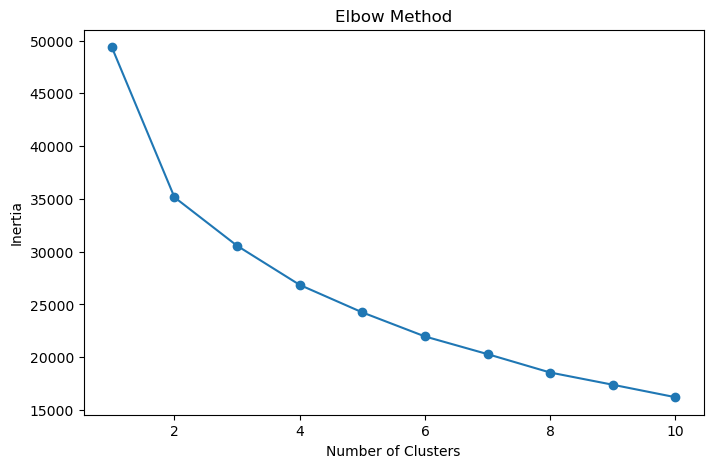

In [16]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# Train K-Means Model

In [17]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X_scaled)

y_kmeans


array([0, 0, 2, ..., 0, 0, 0])

In [18]:
df["Cluster"] = y_kmeans

df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Cluster
0,7,99,Yes,9,1,91.0,0
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,2
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0


# Cluster Distribution

In [19]:
df["Cluster"].value_counts()


Cluster
0    4181
1    2954
2    2738
Name: count, dtype: int64

# Cluster Visualization

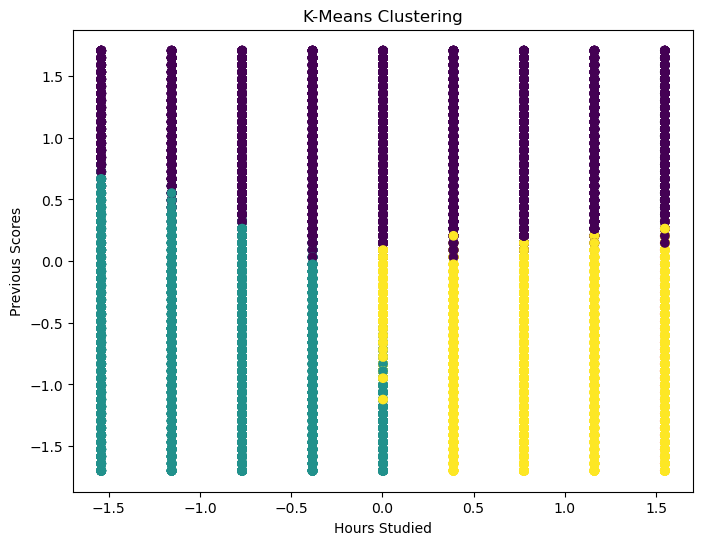

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_kmeans
)

plt.xlabel(numerical_columns[0])
plt.ylabel(numerical_columns[1])
plt.title("K-Means Clustering")

plt.show()


# Cluster Centers

In [21]:
kmeans.cluster_centers_


array([[ 0.08369862,  0.98737272,  0.02948222,  0.0299583 ,  0.94418237],
       [-0.92399135, -0.70458178, -0.05077252, -0.02859653, -1.00921906],
       [ 0.86919928, -0.75071912,  0.00967748, -0.01498665, -0.35580722]])

In [24]:
#silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score: {score:.2f}")


Silhouette Score: 0.21


In [23]:
import pickle

# Save KMeans Model
with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

# Save Scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

Successfully performed K-Means clustering on Student Performance dataset.
